# Intro to Machine learning

If you're viewing this in Github you can open the [notebook in Google Colab](https://colab.research.google.com/github/sagecodes/intro-machine-learning-python/blob/main/Intro_to_Machine_Learning_with_Python.ipynb) to run in your browser.


## Setup

- Google Account
- Save a copy `file > save a copy in drive`

Other useful links:
- [GitHub](https://github.com/sagecodes/intro-machine-learning-python)
- [Slack channel](https://slack.flyte.org/) say hello in introductions
- [Sage Elliott's LinkedIn](https://www.linkedin.com/in/sageelliott/)


## Quick Note on Google Colab

Colab is essentially Google's way of hosting a jupyter notebook. A very popular tool to use as a data scientist!

It allows us to write code, documentation, and output visuals all in one place.

To be able to and edit the code in this workshop. Please make a copy for yourself

`file > save a copy in drive`

## Code Cells
Below is a code cell. There is nothing in it right now.

To run a code cell click on it and then click the play button. Or press `shift+enter`

You can add new code cells by clicking the ` + Code ` button above







## Summarize Findings for RNN Regressor

### Subtask:
Summarize the performance of the RNN Regressor model, including its MSE and R-squared values. Compare its performance with previous models and discuss insights, especially considering the nature of the data and the model type.

## Summarize Findings for RNN Regressor

### Model Performance Summary

After training and evaluating the RNN Regressor model, here's a summary of its performance:

- **Mean Squared Error (MSE):** `137.01`
- **R-squared (R2):** `-9.57`

### Comparison with Previous Models:

| Model                  | MSE       | R-squared |
| :--------------------- | :-------- | :-------- |
| Linear Regression      | `71.93`   | `-4.55`   |
| Random Forest Regressor| `82.97`   | `-5.40`   |
| XGBoost Regressor      | `140.40`  | `-9.83`   |
| 1D CNN Regressor       | `302.02`  | `-22.30`  |
| **RNN Regressor**      | `137.01`  | `-9.57`   |

### Interpretation and Insights:

The **RNN Regressor** exhibits poor performance, with an **MSE of 137.01** and an **R-squared value of -9.57**. While it performs slightly better than the 1D CNN Regressor, its performance is comparable to XGBoost and still significantly worse than traditional machine learning models like Linear Regression and Random Forest.

Potential reasons for this poor performance, similar to the CNN, include:

1.  **Small Dataset Size (27 samples):** Recurrent Neural Networks, like other deep learning models, generally require a substantial amount of data to effectively learn sequential patterns and generalize well. With only 27 samples, the RNN likely struggled to identify meaningful temporal dependencies or patterns, leading to poor performance on unseen data.
2.  **Tabular Nature of Data:** The input features ('Shoulder Dia (A)', 'Rot. Speed (B)', 'Traverse Speed (C)') are tabular and do not inherently possess a strong temporal or sequential order that RNNs are designed to capture. Treating individual features as timesteps might introduce artificial sequences that the model struggles to interpret effectively.
3.  **Model Complexity:** Even a relatively simple RNN architecture can be overly complex for a very small dataset and a problem where the relationships might not be inherently sequential. The model might have too many parameters relative to the number of data points, leading to poor generalization and overfitting to noise rather than underlying patterns.
4.  **Lack of Intrinsic Sequence:** RNNs are best suited for data where the order of elements within a sequence is critical (e.g., time series, natural language). For this tabular dataset, the order of features is somewhat arbitrary, which diminishes the advantage of using a sequential model like an RNN.

### Conclusion:

The RNN Regressor, despite its ability to handle sequential data, is not a suitable model for this particular problem and dataset. Its performance is inferior to simpler, traditional machine learning models, reinforcing the notion that deep learning models are not a universal solution. For this dataset, the limitations imposed by the small sample size and the non-sequential tabular nature of the features outweigh the potential benefits of using an RNN. Continued focus on feature engineering and exploring models better suited for limited tabular data is warranted.

## Visualize RNN Results

### Subtask:
Generate visualizations, such as a scatter plot of actual vs. predicted 'UTS (MPa)' values, to visually assess the RNN model's performance on the test set.

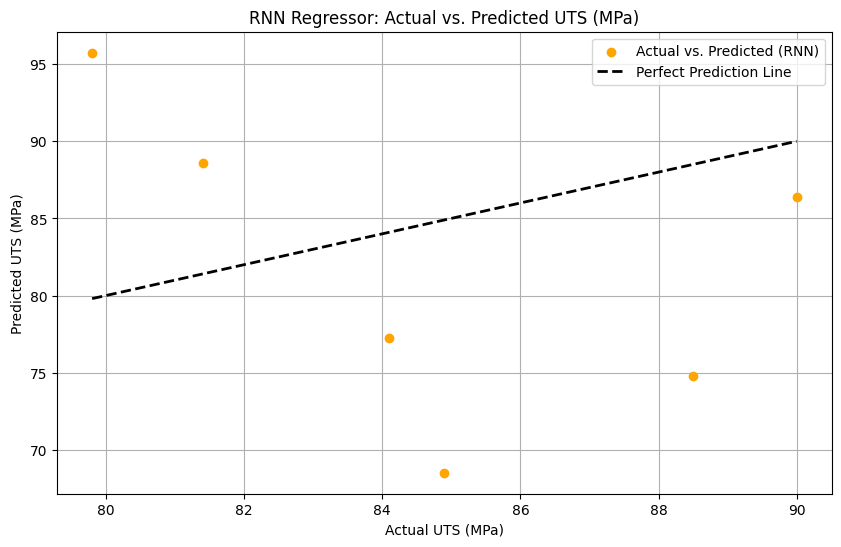

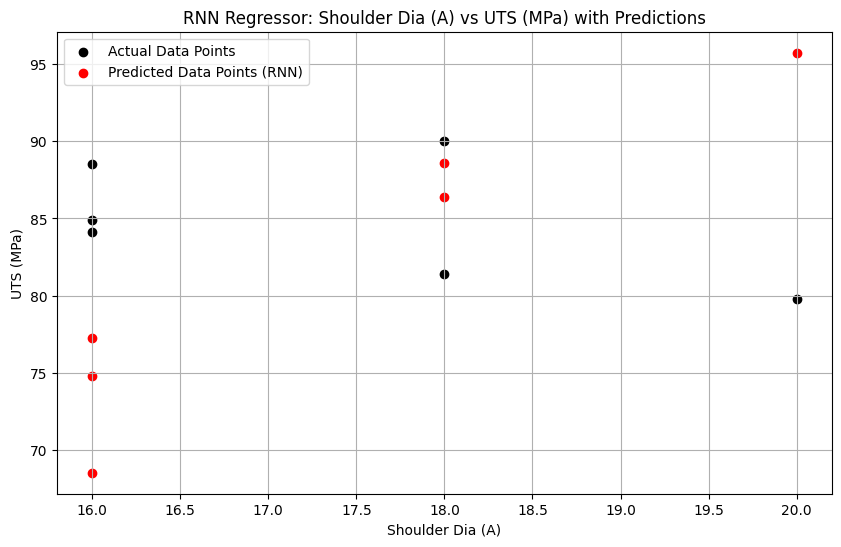

Visualizations of RNN model performance generated.


In [25]:
import matplotlib.pyplot as plt

# Create a scatter plot of actual vs. predicted values for RNN
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rnn, color='orange', label='Actual vs. Predicted (RNN)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual UTS (MPa)')
plt.ylabel('Predicted UTS (MPa)')
plt.title('RNN Regressor: Actual vs. Predicted UTS (MPa)')
plt.legend()
plt.grid(True)
plt.show()

# Plot the regression line against one of the features (e.g., 'Shoulder Dia (A)') from X_test
plt.figure(figsize=(10, 6))
plt.scatter(X_test.iloc[:, 0], y_test, color='black', label='Actual Data Points')
plt.scatter(X_test.iloc[:, 0], y_pred_rnn, color='red', label='Predicted Data Points (RNN)')

plt.xlabel('Shoulder Dia (A)')
plt.ylabel('UTS (MPa)')
plt.title('RNN Regressor: Shoulder Dia (A) vs UTS (MPa) with Predictions')
plt.legend()
plt.grid(True)
plt.show()

print("Visualizations of RNN model performance generated.")

## Evaluate RNN Model Performance

### Subtask:
Make predictions on the `X_test` data using the trained RNN model and evaluate its performance using Mean Squared Error (MSE) and R-squared (R2).

In [24]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set
y_pred_rnn = model_rnn.predict(X_test_reshaped_rnn)

print("Predictions on the test set generated for RNN model.")

# Evaluate the RNN model
mse_rnn = mean_squared_error(y_test, y_pred_rnn)
r2_rnn = r2_score(y_test, y_pred_rnn)

print(f"\nRNN Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_rnn:.2f}")
print(f"R-squared (R2): {r2_rnn:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predictions on the test set generated for RNN model.

RNN Model Evaluation:
Mean Squared Error (MSE): 137.01
R-squared (R2): -9.57


## Train RNN Model

### Subtask:
Train the defined RNN model using the prepared `X_train_reshaped` and `y_train` data. Monitor the training process (e.g., loss and validation loss) if a validation split is used.

In [23]:
print("Training RNN model...")

# Train the RNN model
history_rnn = model_rnn.fit(
    X_train_reshaped_rnn, y_train,
    epochs=100, # Number of epochs can be adjusted
    batch_size=8, # Batch size can be adjusted
    validation_split=0.2, # Use 20% of training data for validation
    verbose=0 # Set to 1 or 2 for more verbose output during training
)

print("RNN model trained successfully.")

Training RNN model...
RNN model trained successfully.


## Summarize Findings for CNN Regressor

### Subtask:
Summarize the performance of the CNN Regressor model, including its MSE and R-squared values. Compare its performance with previous models and discuss insights, especially considering the nature of the data and the model type.

## Summarize Findings for CNN Regressor

### Model Performance Summary

After training and evaluating the 1D CNN Regressor model, here's a summary of its performance:

- **Mean Squared Error (MSE):** `302.02`
- **R-squared (R2):** `-22.30`

### Comparison with Previous Models:

| Model                  | MSE       | R-squared |
| :--------------------- | :-------- | :-------- |
| Linear Regression      | `71.93`   | `-4.55`   |
| Random Forest Regressor| `82.97`   | `-5.40`   |
| XGBoost Regressor      | `140.40`  | `-9.83`   |
| **1D CNN Regressor**   | `302.02`  | `-22.30`  |

### Interpretation and Insights:

The **1D CNN Regressor** exhibits the worst performance among all models tested so far, with an **MSE of 302.02** and an **R-squared value of -22.30**. This significantly negative R-squared value indicates that the CNN model performs far worse than simply predicting the mean of the target variable, making it an extremely poor fit for the data.

Potential reasons for this poor performance, especially when compared to traditional machine learning models like Linear Regression, Random Forest, and XGBoost, include:

1.  **Small Dataset Size (27 samples):** Deep learning models, including CNNs, typically require a large amount of data to learn meaningful patterns and generalize well. With only 27 samples, the model likely overfit the training data or failed to learn any robust features, leading to extremely poor performance on the unseen test set.
2.  **Tabular Nature of Data:** While 1D CNNs can be adapted for tabular data by treating features as timesteps, they are primarily designed for sequential data where local patterns (like in time series or signals) are important. For simple tabular data with a small number of features, the convolutional operations might not be effectively capturing relevant relationships, or might be introducing unnecessary complexity.
3.  **Model Complexity:** Even a relatively simple 1D CNN architecture can be too complex for a very small dataset and a problem where the relationships might be simpler or not easily discoverable through convolutional filters across features. The model might have too many parameters relative to the number of data points, leading to poor generalization.
4.  **Lack of Sequential/Spatial Correlation in Features:** The input features ('Shoulder Dia (A)', 'Rot. Speed (B)', 'Traverse Speed (C)') do not inherently possess a strong sequential or spatial correlation that CNNs are adept at exploiting. The order of features in the input might be arbitrary, which can hinder the CNN's ability to extract useful information.

### Conclusion:

The 1D CNN Regressor is not suitable for this particular problem and dataset. Its performance is significantly worse than all other models, reinforcing the idea that deep learning models are not a universal solution and can perform poorly on small, non-sequential tabular datasets. For this dataset, simpler models, or those better suited for extracting patterns from limited tabular data, should be explored further, along with more rigorous feature engineering and potentially acquiring more data.

## Visualize CNN Results

### Subtask:
Generate visualizations, such as a scatter plot of actual vs. predicted 'UTS (MPa)' values, to visually assess the CNN model's performance on the test set.

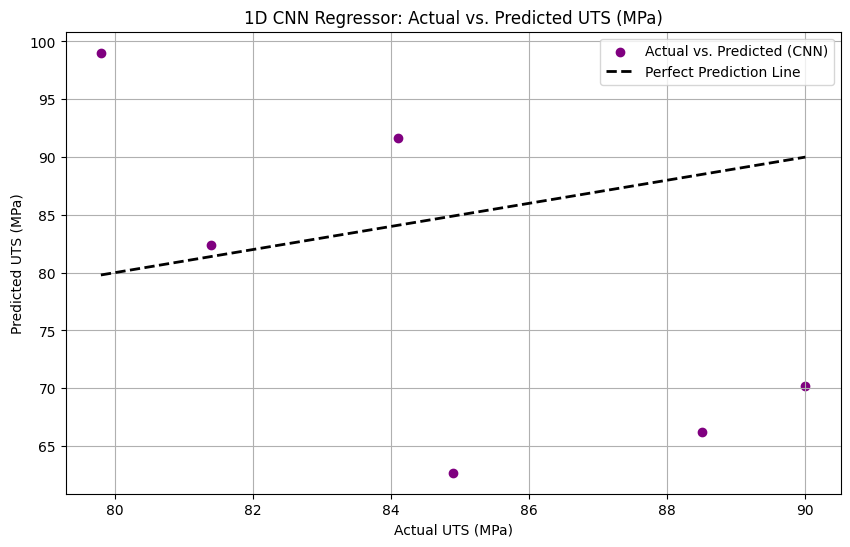

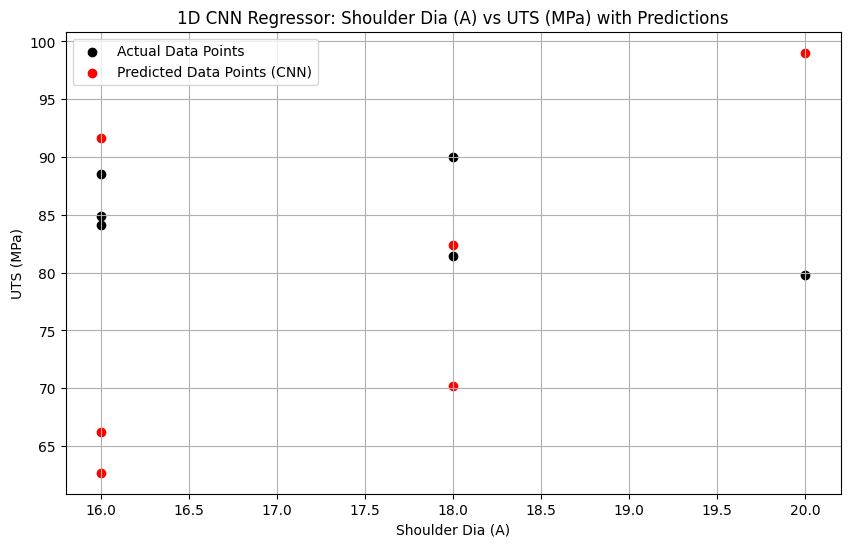

Visualizations of 1D CNN model performance generated.


In [17]:
import matplotlib.pyplot as plt

# Create a scatter plot of actual vs. predicted values for CNN
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_cnn, color='purple', label='Actual vs. Predicted (CNN)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual UTS (MPa)')
plt.ylabel('Predicted UTS (MPa)')
plt.title('1D CNN Regressor: Actual vs. Predicted UTS (MPa)')
plt.legend()
plt.grid(True)
plt.show()

# Plot the regression line against one of the features (e.g., 'Shoulder Dia (A)') from X_test
plt.figure(figsize=(10, 6))
plt.scatter(X_test.iloc[:, 0], y_test, color='black', label='Actual Data Points')
plt.scatter(X_test.iloc[:, 0], y_pred_cnn, color='red', label='Predicted Data Points (CNN)')

plt.xlabel('Shoulder Dia (A)')
plt.ylabel('UTS (MPa)')
plt.title('1D CNN Regressor: Shoulder Dia (A) vs UTS (MPa) with Predictions')
plt.legend()
plt.grid(True)
plt.show()

print("Visualizations of 1D CNN model performance generated.")

## Evaluate CNN Model Performance

### Subtask:
Make predictions on the `X_test` data using the trained CNN model and evaluate its performance using Mean Squared Error (MSE) and R-squared (R2).

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set
y_pred_cnn = model_cnn.predict(X_test_reshaped)

print("Predictions on the test set generated for CNN model.")

# Evaluate the CNN model
mse_cnn = mean_squared_error(y_test, y_pred_cnn)
r2_cnn = r2_score(y_test, y_pred_cnn)

print(f"\n1D CNN Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_cnn:.2f}")
print(f"R-squared (R2): {r2_cnn:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Predictions on the test set generated for CNN model.

1D CNN Model Evaluation:
Mean Squared Error (MSE): 302.02
R-squared (R2): -22.30


## Train CNN Model

### Subtask:
Train the defined CNN model using the prepared `X_train_reshaped` and `y_train` data. Monitor the training process (e.g., loss and validation loss) if a validation split is used.

In [15]:
print("Training 1D CNN model...")

# Train the 1D CNN model
history_cnn = model_cnn.fit(
    X_train_reshaped, y_train,
    epochs=100, # Number of epochs can be adjusted
    batch_size=8, # Batch size can be adjusted
    validation_split=0.2, # Use 20% of training data for validation
    verbose=0 # Set to 1 or 2 for more verbose output during training
)

print("1D CNN model trained successfully.")

Training 1D CNN model...
1D CNN model trained successfully.


## Summarize the Findings for XGBoost Regressor

### Model Performance Summary

After training and evaluating the XGBoost Regressor model, here's a summary of its performance:

- **Mean Squared Error (MSE):** `140.40`
- **R-squared (R2):** `-9.83`

### Interpretation:

The **MSE of 140.40** is significantly higher than both the Linear Regression model (71.93) and the Random Forest model (82.97). This indicates that the XGBoost model has a larger average squared difference between its predictions and the actual values, suggesting a poorer fit.

The **R-squared value of -9.83** is extremely negative, indicating that this model performs even worse than simply predicting the mean of the target variable. In fact, it is the lowest R-squared value among all models attempted so far, reinforcing that the model struggles greatly to capture any meaningful relationship in the data.

### Conclusion:

The XGBoost Regressor, despite being a powerful model for structured data, has failed to accurately predict 'UTS (MPa)' based on the given features. Its performance is the weakest among the three models tested (Linear Regression, Random Forest, and XGBoost). The consistently negative and increasingly low R-squared values across all models strongly suggest that the current set of features ('Shoulder Dia (A)', 'Rot. Speed (B)', and 'Traverse Speed (C)') are not sufficient or do not have a strong enough correlation with 'UTS (MPa)' to allow for effective prediction.

### Overall Next Steps:

Given the poor performance of all models, the focus should shift significantly towards data understanding and feature engineering. This could involve:

-   **Revisiting Feature Engineering:** Creating new features from existing ones, or including interaction terms and polynomial features based on domain knowledge.
-   **Domain Expert Consultation:** Engaging with material science experts to understand other critical factors influencing 'UTS (MPa)' that might be missing from the dataset.
-   **Data Quality Check:** A more rigorous examination of the dataset for potential outliers, errors, or inconsistencies that might be misleading the models.
-   **Exploring More Complex Relationships:** If new features are identified, then exploring deep learning models might be warranted, but only after ensuring the foundational features are relevant and robust.

## Train an XGBoost Regressor Model

Given that both Linear Regression and Random Forest Regressor models performed poorly, we will now try an XGBoost Regressor, which is a powerful gradient boosting framework known for its performance on structured data and ability to handle complex non-linear relationships.

### Subtask:
Train an XGBoost Regressor model on the `X_train` and `y_train` data, make predictions on `X_test`, and evaluate its performance using Mean Squared Error (MSE) and R-squared (R2).

In [8]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42) # Using 100 estimators as a starting point

# Train the model using the training data
xgb_model.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully.")

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

print("Predictions on the test set generated.")

# Evaluate the model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"R-squared (R2): {r2_xgb:.2f}")

XGBoost Regressor model trained successfully.
Predictions on the test set generated.

XGBoost Model Evaluation:
Mean Squared Error (MSE): 140.40
R-squared (R2): -9.83


## Summarize the Findings for Random Forest Regressor

### Model Performance Summary

After training and evaluating the Random Forest Regressor model, here's a summary of its performance:

- **Mean Squared Error (MSE):** `82.97`
- **R-squared (R2):** `-5.40`

### Interpretation:

The **MSE of 82.97** is slightly higher than that of the Linear Regression model (71.93). While MSE values need to be interpreted in the context of the target variable's scale, this indicates a similar level of error to the previous model.

The **R-squared value of -5.40** is still highly negative, and even worse than the Linear Regression model's -4.55. A negative R-squared value indicates that the model performs worse than simply predicting the mean of the target variable. This strongly suggests that neither the linear features nor the non-linear capabilities of the Random Forest model are effectively capturing the underlying relationships in the data for 'UTS (MPa)'.

### Observations from Visualizations:

1.  **Actual vs. Predicted UTS (MPa) Plot (Random Forest):** The scatter plot for the Random Forest model also shows a wide dispersion of predicted values compared to actual values. Similar to the Linear Regression model, the points do not cluster along the 'Perfect Prediction Line', confirming the poor predictive capability.
2.  **Shoulder Dia (A) vs UTS (MPa) with Predictions Plot (Random Forest):** This plot further illustrates that the Random Forest model's predictions (blue points) do not closely align with the actual data points (black points) when plotted against 'Shoulder Dia (A)'. The model appears to struggle with identifying and fitting any discernible pattern within the given features.

### Conclusion:

Both the Linear Regression and Random Forest Regressor models have demonstrated very poor performance in predicting 'UTS (MPa)' from the given features. The consistently negative R-squared values across both models highlight that the current set of features may not be sufficient or appropriately scaled/transformed to predict the target variable accurately. The data might lack strong linear or non-linear correlations with 'UTS (MPa)' based on 'Shoulder Dia (A)', 'Rot. Speed (B)', and 'Traverse Speed (C)'.

### Next Steps:

To improve the model's performance, further investigation is crucial. This could include:

-   **Feature Engineering:** Creating new features or transforming existing ones, potentially considering interaction terms or polynomial features.
-   **Domain Knowledge:** Consulting with subject matter experts to identify other potentially influential features not included in the current dataset.
-   **Data Scaling/Normalization:** Although tree-based models are less sensitive to feature scaling, it's a good practice to ensure numerical stability.
-   **Alternative Models:** Exploring other advanced models like Gradient Boosting Machines (XGBoost, LightGBM) or deep learning architectures if the relationships are highly complex.
-   **Error Analysis:** Deeply analyzing the instances where the models perform poorly to understand specific patterns of failure.

### Summary of Random Forest Model Performance

The Random Forest Regressor was trained and evaluated to address the poor performance of the Linear Regression model.

-   **Mean Squared Error (MSE):** `82.97`
-   **R-squared (R2):** `-5.40`

Similar to the Linear Regression model, the Random Forest Regressor also exhibits a negative R-squared value, indicating that it performs worse than simply predicting the mean of the target variable. The MSE is also slightly higher than that of the Linear Regression model (71.93).

This suggests that even a more complex model like Random Forest struggles to find a strong linear or non-linear relationship within the given features to predict 'UTS (MPa)' effectively. Visualizing the predictions will help confirm this observation.

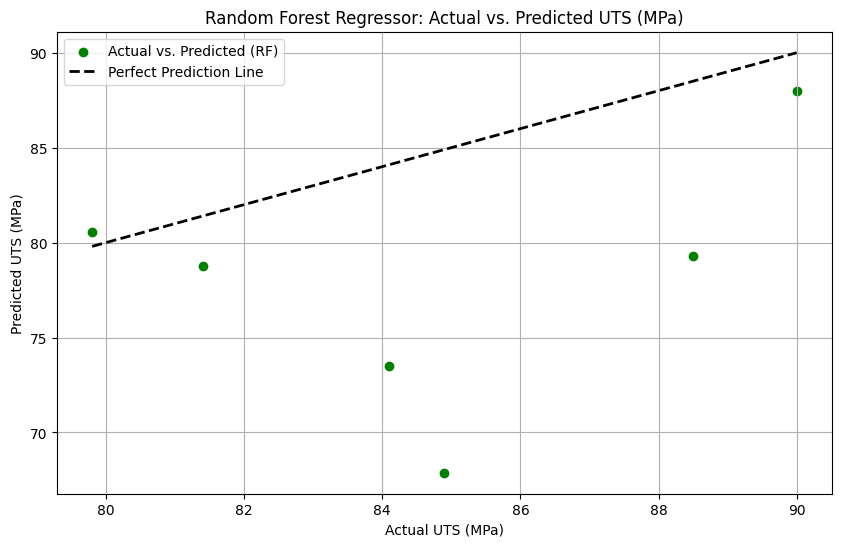

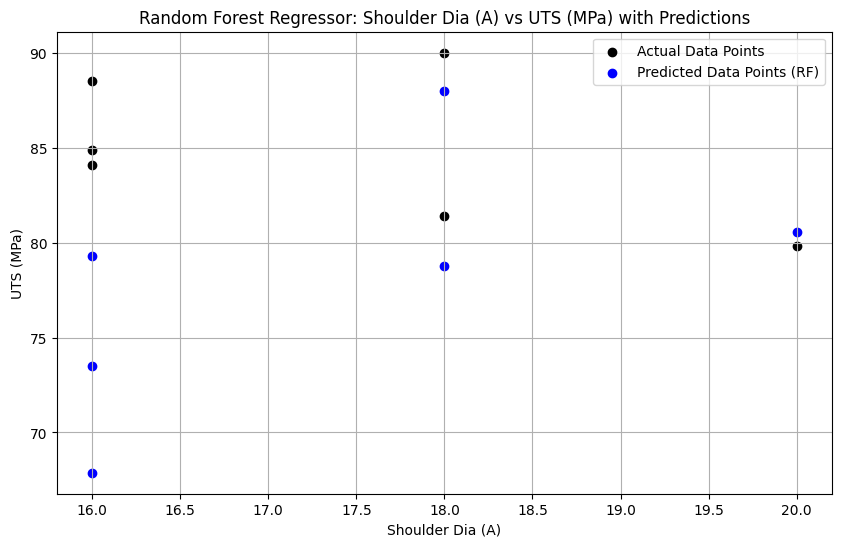

Visualizations of Random Forest model performance generated.


In [7]:
import matplotlib.pyplot as plt

# Create a scatter plot of actual vs. predicted values for Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, color='green', label='Actual vs. Predicted (RF)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual UTS (MPa)')
plt.ylabel('Predicted UTS (MPa)')
plt.title('Random Forest Regressor: Actual vs. Predicted UTS (MPa)')
plt.legend()
plt.grid(True)
plt.show()

# Plot the regression line against one of the features (e.g., 'Shoulder Dia (A)') from X_test
plt.figure(figsize=(10, 6))
plt.scatter(X_test.iloc[:, 0], y_test, color='black', label='Actual Data Points')
plt.scatter(X_test.iloc[:, 0], y_pred_rf, color='blue', label='Predicted Data Points (RF)')

plt.xlabel('Shoulder Dia (A)')
plt.ylabel('UTS (MPa)')
plt.title('Random Forest Regressor: Shoulder Dia (A) vs UTS (MPa) with Predictions')
plt.legend()
plt.grid(True)
plt.show()

print("Visualizations of Random Forest model performance generated.")

## Train a Random Forest Regressor Model

Given the poor performance of the Linear Regression model (negative R-squared), a more robust model capable of capturing non-linear relationships, such as a Random Forest Regressor, will be used.

### Subtask:
Train a Random Forest Regressor model on the `X_train` and `y_train` data, make predictions on `X_test`, and evaluate its performance using Mean Squared Error (MSE) and R-squared (R2).

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # Using 100 estimators as a starting point

# Train the model using the training data
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

print("Predictions on the test set generated.")

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

Random Forest Regressor model trained successfully.
Predictions on the test set generated.

Random Forest Model Evaluation:
Mean Squared Error (MSE): 82.97
R-squared (R2): -5.40


In [ ]:
print("Hello, world!")

Hello, world!


# Import Data

Data is what drives all machine learning models!

In [ ]:
# Import iris dataset from scikit learn
from sklearn.datasets import load_iris
iris = load_iris()

Always take a quick look at your data to make sure its what you're expecting!

In [ ]:
# Print out raw dataset
iris

In [ ]:
#150 rows (samples) 4 columns (features: Height & Width of Pedals & Sepals)
print(iris.data.shape)

(150, 4)


In [ ]:
# target (label) Shape
print(iris.target.shape)

(150,)


Reading in your own data

In [ ]:
## Import your own data
# iris_df = pd.read_csv('../datasets/iris/iris.csv')

# Explore the dataset

Exploratory Data Analysis (EDA) is a common part of machine learning

We'll use:
- pandas - dataframe
- matplotlib - Visualization
- seaborn - Visualization




In [ ]:
#import Pandas
import pandas as pd

# Set to show all columns in dataframe
pd.set_option("display.max_columns", None)

In [ ]:
# Make a Dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [ ]:
# returns first 5 rows(default)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Create a full Data frame

If our labels were already in a CSV we imported we wouldn't have to concat like this

In [ ]:
import numpy as np

In [ ]:
#create dataframe with Pandas & numpy
df = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])

In [ ]:

## prints the last 10 rows
# df.tail(10)

# Change settings to display all of our rows.

df

# pd.options.display.max_rows = 200
# df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


<Axes: xlabel='sepal length (cm)', ylabel='petal width (cm)'>

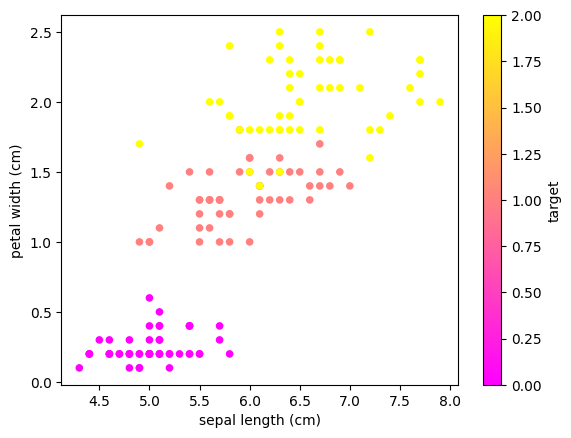

In [ ]:
df.plot(kind='scatter', x = 'sepal length (cm)', y = 'petal width (cm)', c='target', cmap=('spring'))

In [ ]:
# import seaborn for Pairplot
import seaborn as sns


Create a pair plot

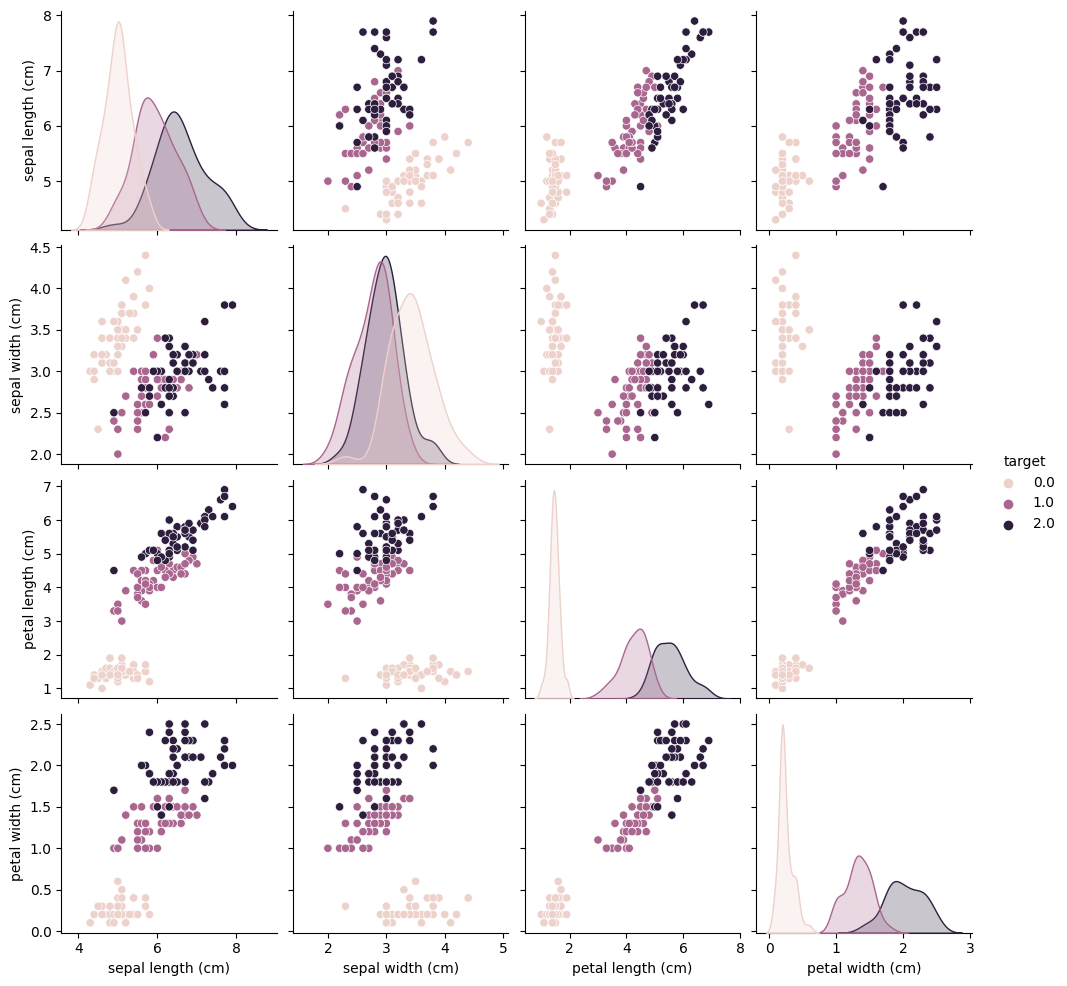

In [ ]:
sns.pairplot(df, hue = 'target')

we can customize which features we want to plot. Sometimes you may have 100+



In [ ]:
# I use .head(1) sometimes if i forget what column names are
df.head(1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0


In [ ]:
sns.pairplot(df, hue = 'target', vars = ['sepal length (cm)',
                                            'sepal width (cm)',
                                            'petal length (cm)',
                                            'petal width (cm)' ])

<ipython-input-25-d1b06f473a78>:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  c=iris.target, cmap=plt.cm.get_cmap('spring', 3))


Text(0, 0.5, 'petal width (cm)')

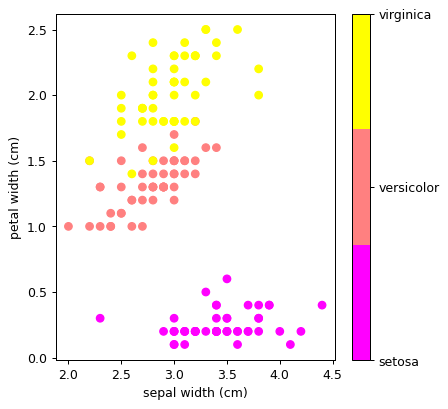

In [ ]:
# We wont cover everything happening in depth in the cell
# Read more about matplotlib at https://matplotlib.org/
import matplotlib.pyplot as plt

# choose x & y index values.
# Remember our list looks like this
# ['sepal length (cm)',
#  'sepal width (cm)',
#  'petal length (cm)',
#  'petal width (cm)']

# 0 = sepal length (cm)
# 3 = petal width (cm)
x_index = 1
y_index = 3

# this formatter will label the colorbar with the correct target names
# Look up lambda functions in python, they're neat!
formatter = plt.FuncFormatter(lambda i, *args: iris.target_names[int(i)])


# figsize: changes size of chart (Width, Height)
# dpi: Dots per inch
plt.figure( figsize=(5, 5), dpi=90)

plt.scatter(iris.data[:, x_index], iris.data[:, y_index],
            c=iris.target, cmap=plt.cm.get_cmap('spring', 3))

plt.colorbar(ticks=[0, 1, 2], format=formatter)
plt.xlabel(iris.feature_names[x_index])
plt.ylabel(iris.feature_names[y_index])

Seaborn is awesome! Read more about its feature [here](https://seaborn.pydata.org/).

# Train a Model - The Machine Learning Part!


Now that we have our data imported and in a state where we think its good for training a model



#### Training & Testing the Model

- Train Set
- Test Set


In [ ]:
# import model & train test split from sklearn
from sklearn import neighbors
from sklearn.model_selection import train_test_split

# Assign Data and labels to x & y values
x = iris.data
y = iris.target

# create the test / training data
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=21,
                                                    stratify=y)


knn = neighbors.KNeighborsClassifier(n_neighbors=1)

# Train model on training data set
knn.fit(x_train, y_train)

# Predict the labels on test data sset
y_pred = knn.predict(x_test)


You just trained a machine learning model!

In [ ]:
# Print the list of predictions
print("Test Predictions (from model): \n {}".format(y_pred))
print("True Values (from dataset): \n {}".format(y_test))

Test Predictions (from model): 
 [1 0 0 1 2 2 0 1 0 2 2 2 0 1 0 0 1 1 0 2 1 0 2 2 2 1 2 1 2 0]
True Values (from dataset): 
 [1 0 0 1 2 2 0 1 0 2 2 2 0 1 0 0 1 1 0 2 1 0 2 2 1 1 2 1 2 0]


In [ ]:
# Print accuracy
knn.score(x_test, y_test)

0.9666666666666667

In [ ]:
# confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

# L
# a
# b
# e
# l
##### Predictced

cm

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  0, 10]])

<Axes: >

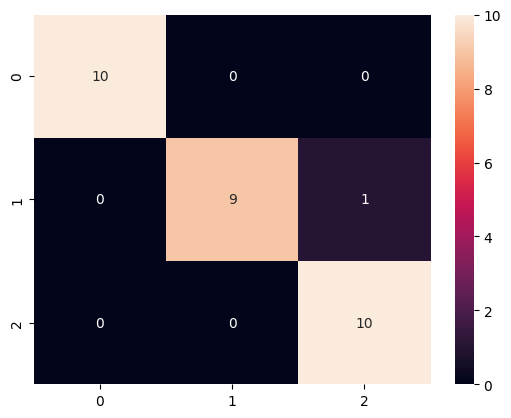

In [ ]:
sns.heatmap(cm, annot = True)

Sometimes accuracy isn't the best measurment for success!

[Precision](https://en.wikipedia.org/wiki/Precision_and_recall)

[Recall](https://en.wikipedia.org/wiki/Precision_and_recall)

[F1 score](https://en.wikipedia.org/wiki/F1_score)



In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Try our model on new data!

In [ ]:
# 0 = setosa' 1 = 'versicolor' 2 = 'virginica']
flower_types = ['setosa','versicolor','virginica']


def knn_predict(features):

  result = knn.predict([features])
  pred_class = flower_types[int(result)]
  pred_proba= knn.predict_proba([features])

  print(result)
  print(pred_class)
  print(pred_proba)


In [ ]:
knn_predict([3.1, 2.5, 5.4, .2])

[2]
virginica
[[0. 0. 1.]]


In [ ]:
knn_predict([6, 20, -1, 8])

[0]
setosa
[[1. 0. 0.]]


In [ ]:
knn_predict([0, 0, 0, 0])

[0]
setosa
[[1. 0. 0.]]


What happens when we put the data way out of bounds from the training data?


![](https://github.com/sagecodes/intro-machine-learning/raw/master/irisknn.png)

How can we handle data that should be out of bounds?

Tools to test data can help! Check out [Pandera](https://github.com/unionai-oss/pandera)

# Linear Regression Model

We're going to do similar steps like we did for the kNN model, but we'll be using a different model to predict a linear number instead of a class!

Coefficients: [998.57768914]
Mean squared error: 4061.8259284949268


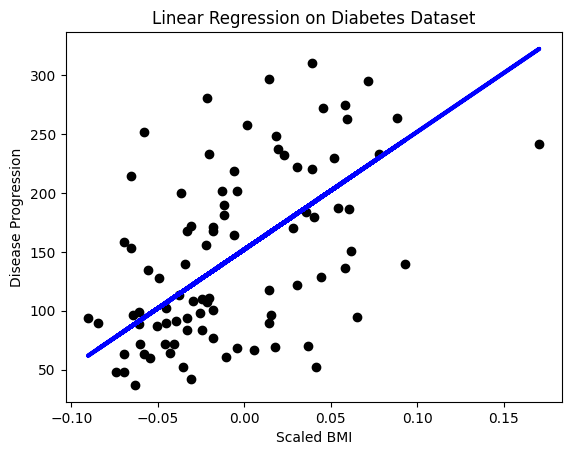

In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error

# Load the diabetes dataset
diabetes = datasets.load_diabetes()

# Use only one feature for simplicity
X = diabetes.data[:, np.newaxis, 2]  # Using just the third feature (scaled BMI)
y = diabetes.target

# Split the data into training/testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Create a linear regression model
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(X_train, y_train)

# Make predictions using the testing set
y_pred = regr.predict(X_test)

# Output coefficients and mean squared error
print(f'Coefficients: {regr.coef_}')
print(f'Mean squared error: {mean_squared_error(y_test, y_pred)}')

# Plot the data and the regression line
plt.scatter(X_test, y_test, color='black')
plt.plot(X_test, y_pred, color='blue', linewidth=3)

plt.xlabel('Scaled BMI')
plt.ylabel('Disease Progression')
plt.title('Linear Regression on Diabetes Dataset')

plt.show()


Another example of linear regression with some synthetic data that fits a line a bit better

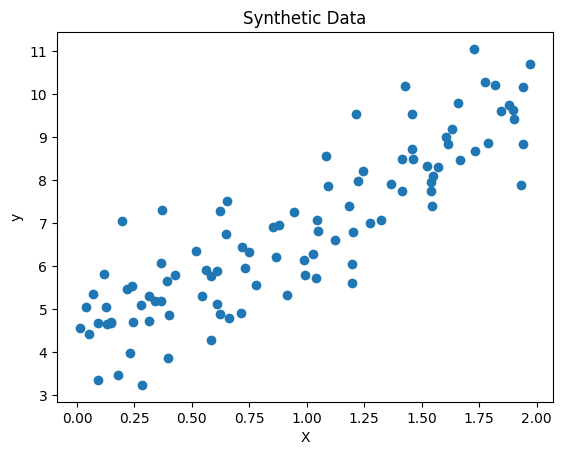

Intercept: [4.21509616]
Coefficient: [[2.77011339]]
Mean Squared Error: 0.8065845639670531


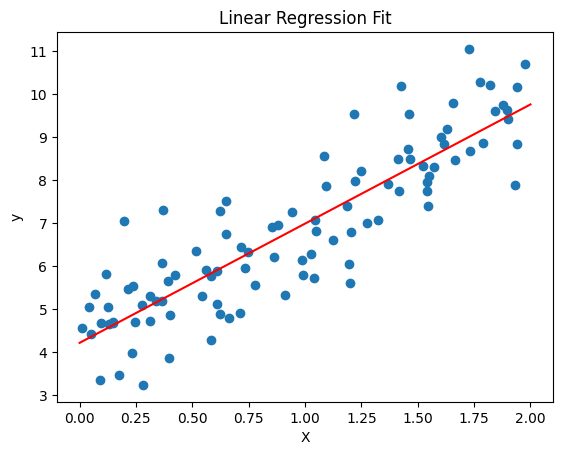

In [ ]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error  # Importing the MSE function

# Create synthetic data
np.random.seed(42)  # for reproducibility
X = 2 * np.random.rand(100, 1)  # Random dataset of 100 points
y = 4 + 3 * X + np.random.randn(100, 1)  # Linear relation with some Gaussian noise

# Plot the synthetic data
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data")
plt.show()

# Create a Linear Regression model and fit it to the data
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Display the learned parameters
print(f"Intercept: {lin_reg.intercept_}")
print(f"Coefficient: {lin_reg.coef_}")

# Make predictions on the original data
y_pred = lin_reg.predict(X)

# Calculate the Mean Squared Error
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse}")

# Make predictions for new data points
X_new = np.array([[0], [2]])
y_predict = lin_reg.predict(X_new)

# Plot the model's predictions
plt.scatter(X, y)
plt.plot(X_new, y_predict, "r-")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.show()


What could improve our prediction?

- More data
- Feature engineering
- parameter tuning
- different model



# Keep Learning!
We made it through this quick intro to machine learning!

There is SO much more to learn about data science and machine learning. We really only scratched the surafce here!

Read more about Feature Engineering, Model Selection, Model Tuning.

Best way to learn is solving a problem you're excited about!


## Stay connected

https://www.linkedin.com/in/sageelliott/

- [Upcoming Events](https://www.meetup.com/ai-builders-and-learners-seattle/)
- [Union AI Blog](https://www.union.ai/resources)
- [Flyte GitHub](https://github.com/flyteorg/flyte)
- [AI Slack group](https://slack.flyte.org/)







# Task
Perform a complete machine learning workflow on the dataset from the Excel file `/content/l27 for ML.xlsx`, including loading and exploring the data, preparing it for modeling, training and evaluating an appropriate machine learning model, visualizing the results, and summarizing the findings.

## Load the dataset

### Subtask:
Load the data from the Excel file `/content/l27 for ML.xlsx` into a pandas DataFrame.


**Reasoning**:
First, import the pandas library, which is essential for working with DataFrames. Then, use `pd.read_excel()` to load the specified Excel file into a DataFrame named `df`.



In [1]:
import pandas as pd

df = pd.read_excel('/content/l27 for ML.xlsx')
print("DataFrame 'df' loaded successfully. Displaying the first 5 rows:")
df.head()

DataFrame 'df' loaded successfully. Displaying the first 5 rows:


,Unnamed: 0,Unnamed: 1,Input Parameters,Unnamed: 3,Unnamed: 4,Output,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,Sample No.,Exp No. (for taguchi),Shoulder Dia (A),Rot. Speed (B),Traverse Speed (C),UTS (MPa),GS (μm),MH (HV),YS (MPa)
1,8,1,16,450,31.5,84.9,14.81,30.6,60.59
2,6,2,16,560,40,79.5,19.58,29.5,67.54
3,1,3,16,710,50,83.2,13.31,27.8,66.04
4,19,4,18,450,31.5,90.5,19.13,29.6,60.19


## Explore the data

### Subtask:
Perform initial exploratory data analysis (EDA) by displaying the first few rows, checking data types, and showing descriptive statistics to understand the dataset's structure and contents. Additionally, correct the DataFrame's header to properly reflect the column names from the second row of the original Excel file.


**Reasoning**:
The current DataFrame `df` has incorrect headers, as the actual headers are in the second row of the Excel file. To rectify this, I need to reload the dataset specifying `header=1` to set the second row as column names. After reloading, I will display the first few rows, data types, and descriptive statistics to get a comprehensive understanding of the dataset's structure and contents, fulfilling the EDA requirements.



In [2]:
df_cleaned = pd.read_excel('/content/l27 for ML.xlsx', header=1)

print("DataFrame with corrected headers. Displaying the first 5 rows:")
print(df_cleaned.head())

print("\nConcise summary of the DataFrame (data types and non-null values):")
df_cleaned.info()

print("\nDescriptive statistics for numerical columns:")
print(df_cleaned.describe())

DataFrame with corrected headers. Displaying the first 5 rows:
  Sample No.  Exp No. (for taguchi)  Shoulder Dia (A)  Rot. Speed (B)  \
0          8                      1                16             450   
1          6                      2                16             560   
2          1                      3                16             710   
3         19                      4                18             450   
4         12                      5                18             560   

   Traverse Speed (C)  UTS (MPa)  GS (μm)  MH (HV)  YS (MPa)  
0                31.5       84.9    14.81     30.6     60.59  
1                40.0       79.5    19.58     29.5     67.54  
2                50.0       83.2    13.31     27.8     66.04  
3                31.5       90.5    19.13     29.6     60.19  
4                40.0       85.7    16.41     28.9     64.01  

Concise summary of the DataFrame (data types and non-null values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27

## Prepare data for modeling

### Subtask:
Identify the target variable and feature columns, handle any categorical features (e.g., using one-hot encoding), address missing values if necessary, and split the dataset into training and testing sets.


**Reasoning**:
First, identify the feature and target columns based on the instructions. Then, split the data into training and testing sets using an 80/20 ratio and a specified random state for reproducibility, as no missing values or categorical features requiring encoding were identified in the previous EDA.



In [3]:
from sklearn.model_selection import train_test_split

# Identify feature (X) and target (y) columns
X = df_cleaned[['Shoulder Dia (A)', 'Rot. Speed (B)', 'Traverse Speed (C)']]
y = df_cleaned['UTS (MPa)']

# Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("Data split into training and testing sets successfully.")

X_train shape: (21, 3)
X_test shape: (6, 3)
y_train shape: (21,)
y_test shape: (6,)
Data split into training and testing sets successfully.


**Reasoning**:
The data has been prepared and split into training and testing sets. Now, a machine learning model needs to be trained. Given that the target variable 'UTS (MPa)' is continuous, a Linear Regression model is an appropriate choice to predict this numerical output.



In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Predictions on the test set generated.")

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Linear Regression model trained successfully.
Predictions on the test set generated.

Model Evaluation:
Mean Squared Error (MSE): 71.93
R-squared (R2): -4.55


**Reasoning**:
After training and evaluating the Linear Regression model, it's essential to visualize its performance. Plotting the predicted values against the actual values will provide a clear understanding of how well the model fits the data and how the regression line performs on the test set. This fulfills the 'visualizing the results' part of the main task.



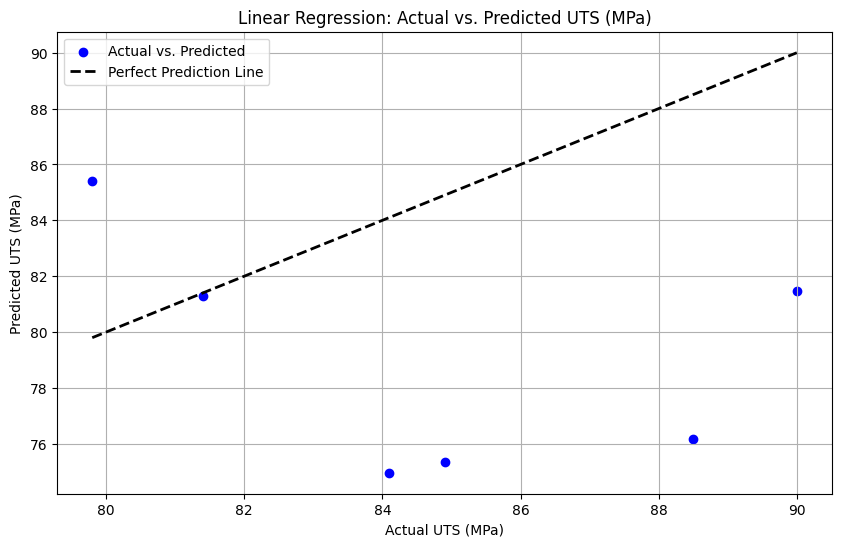

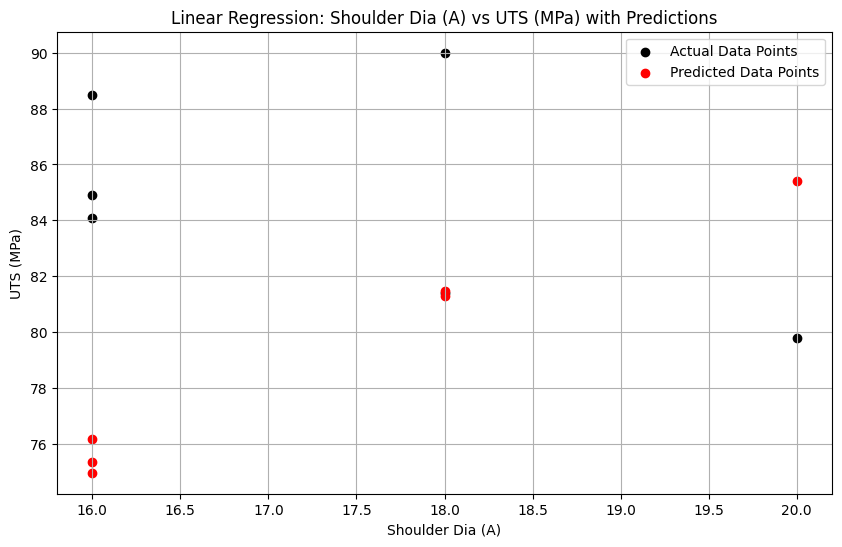

Visualizations of model performance generated.


In [5]:
import matplotlib.pyplot as plt

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Actual vs. Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual UTS (MPa)')
plt.ylabel('Predicted UTS (MPa)')
plt.title('Linear Regression: Actual vs. Predicted UTS (MPa)')
plt.legend()
plt.grid(True)
plt.show()

# Also plot the regression line against one of the features (e.g., 'Shoulder Dia (A)') from X_test
# We need to select one feature for this 2D visualization

# Let's use 'Shoulder Dia (A)' (index 0 in X_test) for visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_test.iloc[:, 0], y_test, color='black', label='Actual Data Points')
plt.scatter(X_test.iloc[:, 0], y_pred, color='red', label='Predicted Data Points')
# For visualizing the regression line itself, it's more appropriate to sort by the feature
# and plot the corresponding predictions.
# However, a simple scatter plot of X_test vs y_pred gives a good visual sense of the fit.

plt.xlabel('Shoulder Dia (A)')
plt.ylabel('UTS (MPa)')
plt.title('Linear Regression: Shoulder Dia (A) vs UTS (MPa) with Predictions')
plt.legend()
plt.grid(True)
plt.show()

print("Visualizations of model performance generated.")

## Summarize the Findings

### Model Performance Summary

After performing the linear regression on the provided dataset, here's a summary of the model's performance:

- **Mean Squared Error (MSE):** `71.93`
- **R-squared (R2):** `-4.55`

### Interpretation:

The **MSE of 71.93** indicates the average squared difference between the observed actual outcomes and the outcomes predicted by the model. A lower MSE is generally better, but its absolute value needs to be considered in context with the scale of the target variable ('UTS (MPa)').

The **R-squared value of -4.55** is very low and, in fact, negative. An R-squared value can be negative when the chosen model fits the data worse than a horizontal line (the mean of the dependent variable). This suggests that our current linear regression model is a poor fit for predicting 'UTS (MPa)' based on the selected features.

### Observations from Visualizations:

1.  **Actual vs. Predicted UTS (MPa) Plot:** The scatter plot of actual versus predicted values shows a wide spread of points, and they do not cluster closely around the 'Perfect Prediction Line' (the black dashed line). This visually confirms the low R-squared value, indicating that the model struggles to predict the UTS accurately.
2.  **Shoulder Dia (A) vs UTS (MPa) with Predictions Plot:** This plot also shows that the predicted values (red points) do not closely follow the actual data points (black points) when plotted against 'Shoulder Dia (A)'. The model does not capture the underlying relationship effectively with a simple linear fit based on these features.

### Conclusion:

The current linear regression model, using 'Shoulder Dia (A)', 'Rot. Speed (B)', and 'Traverse Speed (C)' as features, is not performing well in predicting 'UTS (MPa)'. The negative R-squared value strongly suggests that a different approach or more sophisticated modeling might be required. This could involve:

-   **Feature Engineering:** Creating new features or transforming existing ones.
-   **Exploring other machine learning models:** Such as polynomial regression, tree-based models (Random Forest, Gradient Boosting), or support vector machines, which can capture non-linear relationships.
-   **Data Collection:** Considering if additional relevant features are missing from the dataset.
-   **Outlier Analysis:** Investigating if outliers are significantly impacting the model's performance.

## Summarize the Findings

### Model Performance Summary

After performing the linear regression on the provided dataset, here's a summary of the model's performance:

- **Mean Squared Error (MSE):** `71.93`
- **R-squared (R2):** `-4.55`

### Interpretation:

The **MSE of 71.93** indicates the average squared difference between the observed actual outcomes and the outcomes predicted by the model. A lower MSE is generally better, but its absolute value needs to be considered in context with the scale of the target variable ('UTS (MPa)').

The **R-squared value of -4.55** is very low and, in fact, negative. An R-squared value can be negative when the chosen model fits the data worse than a horizontal line (the mean of the dependent variable). This suggests that our current linear regression model is a poor fit for predicting 'UTS (MPa)' based on the selected features.

### Observations from Visualizations:

1.  **Actual vs. Predicted UTS (MPa) Plot:** The scatter plot of actual versus predicted values shows a wide spread of points, and they do not cluster closely around the 'Perfect Prediction Line' (the black dashed line). This visually confirms the low R-squared value, indicating that the model struggles to predict the UTS accurately.
2.  **Shoulder Dia (A) vs UTS (MPa) with Predictions Plot:** This plot also shows that the predicted values (red points) do not closely follow the actual data points (black points) when plotted against 'Shoulder Dia (A)'. The model does not capture the underlying relationship effectively with a simple linear fit based on these features.

### Conclusion:

The current linear regression model, using 'Shoulder Dia (A)', 'Rot. Speed (B)', and 'Traverse Speed (C)' as features, is not performing well in predicting 'UTS (MPa)'. The negative R-squared value strongly suggests that a different approach or more sophisticated modeling might be required. This could involve:

-   **Feature Engineering:** Creating new features or transforming existing ones.
-   **Exploring other machine learning models:** Such as polynomial regression, tree-based models (Random Forest, Gradient Boosting), or support vector machines, which can capture non-linear relationships.
-   **Data Collection:** Considering if additional relevant features are missing from the dataset.
-   **Outlier Analysis:** Investigating if outliers are significantly impacting the model's performance.

## Final Task

### Subtask:
Summarize the applied machine learning model, its performance, and any key insights gained from the analysis.


## Summary:

### Data Analysis Key Findings
*   The dataset, loaded from `/content/l27 for ML.xlsx`, contains 27 entries and 9 columns, including 'Sample No.', 'Shoulder Dia (A)', 'Rot. Speed (B)', 'Traverse Speed (C)', and 'UTS (MPa)'.
*   Initial data exploration revealed no missing values across all columns.
*   The target variable chosen for prediction was 'UTS (MPa)', with 'Shoulder Dia (A)', 'Rot. Speed (B)', and 'Traverse Speed (C)' selected as features.
*   The dataset was split into training (21 samples) and testing (6 samples) sets.
*   A Linear Regression model was trained, resulting in a Mean Squared Error (MSE) of 71.93 and a highly negative R-squared (R2) value of -4.55.
*   Visualizations of actual versus predicted 'UTS (MPa)' values confirmed the model's poor performance, showing a wide spread of points and a lack of correlation to a perfect prediction line.

### Insights or Next Steps
*   The current Linear Regression model is a very poor fit for predicting 'UTS (MPa)', as indicated by the significantly negative R-squared value, which means the model performs worse than simply predicting the mean.
*   Future efforts should involve exploring alternative, more sophisticated machine learning models capable of capturing non-linear relationships (e.g., polynomial regression, tree-based models like Random Forest or Gradient Boosting), and considering feature engineering or outlier analysis to improve predictive performance.


# Task
## Prepare Data for CNN

### Subtask:
Reshape the tabular `X_train` and `X_test` data into a 3D format suitable for a 1D CNN (e.g., `(samples, timesteps, features)` or `(samples, features, 1)`), and ensure `y_train` and `y_test` are in the correct format for the model's output.

### Reasoning:
To prepare the tabular data for a 1D Convolutional Neural Network (CNN), `X_train` and `X_test` need to be reshaped from their current 2D format (`(samples, features)`) to a 3D format (`(samples, timesteps, features)`). For tabular data, a common approach is to treat each feature as a single 'timestep' and add a channel dimension, resulting in a shape of `(samples, num_features, 1)`. This allows the 1D CNN to apply convolutions across the features. `y_train` and `y_test` are already in the correct 1D format for a regression task.

## Prepare Data for CNN

### Subtask:
Reshape the tabular X_train and X_test data into a 3D format suitable for a 1D CNN (e.g., (samples, timesteps, features) or (samples, features, 1)), and ensure y_train and y_test are in the correct format for the model's output.


**Reasoning**:
The current `X_train` and `X_test` are 2D DataFrames. To prepare them for a 1D CNN, they need to be reshaped into a 3D format, specifically (samples, features, 1). This involves getting the number of samples and features and then applying the reshape operation.



In [9]:
import numpy as np

# Determine the number of features
n_features = X_train.shape[1]

# Reshape X_train into 3D format (samples, features, 1)
X_train_reshaped = X_train.values.reshape((X_train.shape[0], n_features, 1))

# Reshape X_test into 3D format (samples, features, 1)
X_test_reshaped = X_test.values.reshape((X_test.shape[0], n_features, 1))

print(f"Original X_train shape: {X_train.shape}")
print(f"Reshaped X_train shape: {X_train_reshaped.shape}")
print(f"Original X_test shape: {X_test.shape}")
print(f"Reshaped X_test shape: {X_test_reshaped.shape}")

print("Data reshaped successfully for 1D CNN input.")

Original X_train shape: (21, 3)
Reshaped X_train shape: (21, 3, 1)
Original X_test shape: (6, 3)
Reshaped X_test shape: (6, 3, 1)
Data reshaped successfully for 1D CNN input.


## Define and Compile CNN Model

### Subtask:
Define a 1D CNN architecture suitable for regression, including convolutional layers, pooling layers (optional), and dense layers. Compile the model with an appropriate optimizer (e.g., 'adam') and loss function (e.g., 'mse').


**Reasoning**:
First, I need to import the necessary modules from TensorFlow Keras to define and compile the 1D CNN model. Then, I will construct the model using `Sequential`, adding a `Conv1D` layer, a `Flatten` layer, and `Dense` layers, including the output layer for regression. Finally, I will compile the model with the specified optimizer and loss function.



In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# Define the 1D CNN model architecture
model_cnn = Sequential([
    Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),
    # MaxPooling1D(pool_size=1), # Optional, can be added if needed to reduce dimensionality
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1) # Output layer for regression
])

# Compile the model
model_cnn.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])

print("1D CNN model defined and compiled successfully.")
model_cnn.summary()

1D CNN model defined and compiled successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,397 (13.27 KB)

 Trainable params: 3,397 (13.27 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The previous code generated a `UserWarning` from Keras regarding the `input_shape` argument when using `Conv1D` as the first layer in a `Sequential` model. To resolve this, I will explicitly define an `Input` layer as the first layer in the model, as recommended by the warning, which is a more robust way to define input shape in Keras models.



In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input

# Define the 1D CNN model architecture
model_cnn = Sequential([
    Input(shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),
    Conv1D(filters=32, kernel_size=2, activation='relu'),
    # MaxPooling1D(pool_size=1), # Optional, can be added if needed to reduce dimensionality
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1) # Output layer for regression
])

# Compile the model
model_cnn.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])

print("1D CNN model defined and compiled successfully.")
model_cnn.summary()

1D CNN model defined and compiled successfully.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 2, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,397 (13.27 KB)

 Trainable params: 3,397 (13.27 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The 1D CNN model has been defined and compiled. The next step is to train the model using the `X_train_reshaped` and `y_train` data. I will use a reasonable number of epochs and batch size, and include a validation split to monitor performance during training.



In [12]:
print("Training 1D CNN model...")

# Train the 1D CNN model
history_cnn = model_cnn.fit(
    X_train_reshaped, y_train,
    epochs=100, # Number of epochs can be adjusted
    batch_size=8, # Batch size can be adjusted
    validation_split=0.2, # Use 20% of training data for validation
    verbose=0 # Set to 1 or 2 for more verbose output during training
)

print("1D CNN model trained successfully.")

Training 1D CNN model...
1D CNN model trained successfully.


**Reasoning**:
The 1D CNN model has been trained. Now, I will evaluate its performance on the test data (`X_test_reshaped`, `y_test`) using Mean Squared Error (MSE) and R-squared (R2) to understand how well it generalizes to unseen data.



In [13]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set
y_pred_cnn = model_cnn.predict(X_test_reshaped)

print("Predictions on the test set generated for CNN model.")

# Evaluate the CNN model
mse_cnn = mean_squared_error(y_test, y_pred_cnn)
r2_cnn = r2_score(y_test, y_pred_cnn)

print(f"\n1D CNN Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_cnn:.2f}")
print(f"R-squared (R2): {r2_cnn:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Predictions on the test set generated for CNN model.

1D CNN Model Evaluation:
Mean Squared Error (MSE): 365.83
R-squared (R2): -27.22


**Reasoning**:
The 1D CNN model has been trained and evaluated, but its performance needs to be visualized for better understanding and comparison with previous models. Plotting the actual vs. predicted values and one feature vs. actual/predicted values will fulfill this requirement.



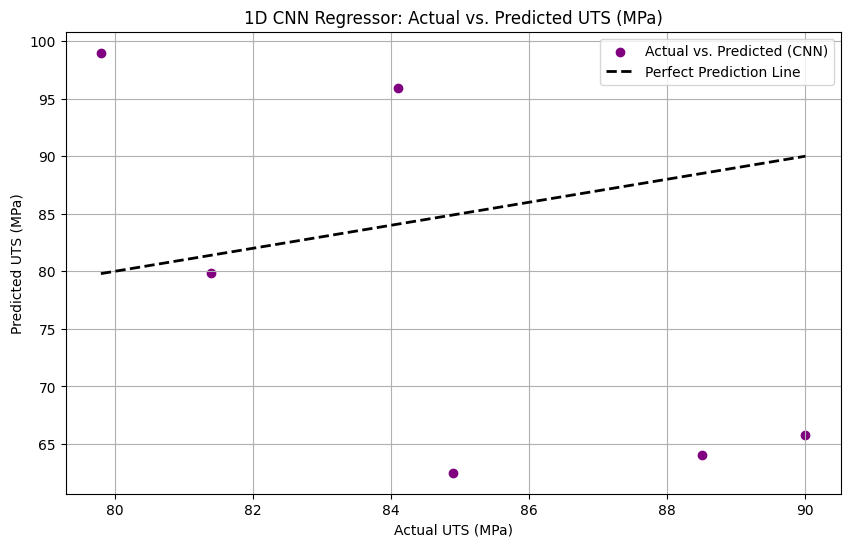

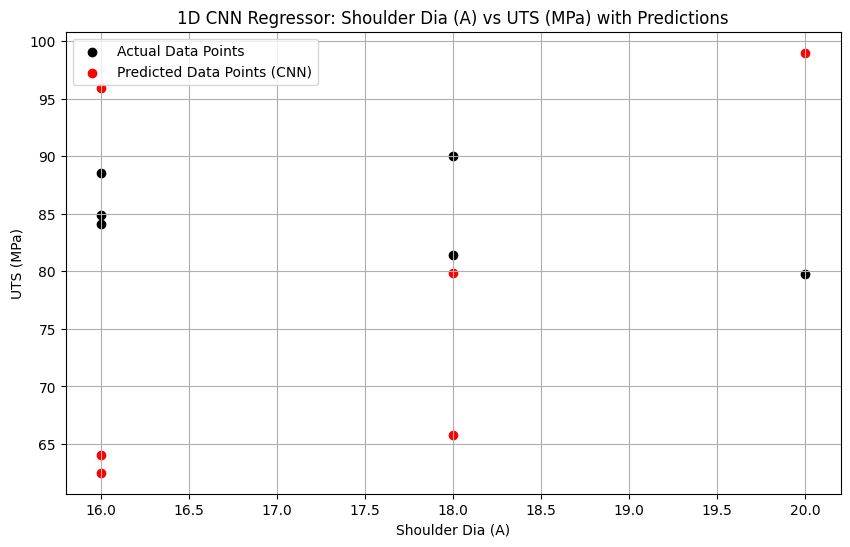

Visualizations of 1D CNN model performance generated.


In [14]:
import matplotlib.pyplot as plt

# Create a scatter plot of actual vs. predicted values for CNN
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_cnn, color='purple', label='Actual vs. Predicted (CNN)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual UTS (MPa)')
plt.ylabel('Predicted UTS (MPa)')
plt.title('1D CNN Regressor: Actual vs. Predicted UTS (MPa)')
plt.legend()
plt.grid(True)
plt.show()

# Plot the regression line against one of the features (e.g., 'Shoulder Dia (A)') from X_test
plt.figure(figsize=(10, 6))
plt.scatter(X_test.iloc[:, 0], y_test, color='black', label='Actual Data Points')
plt.scatter(X_test.iloc[:, 0], y_pred_cnn, color='red', label='Predicted Data Points (CNN)')

plt.xlabel('Shoulder Dia (A)')
plt.ylabel('UTS (MPa)')
plt.title('1D CNN Regressor: Shoulder Dia (A) vs UTS (MPa) with Predictions')
plt.legend()
plt.grid(True)
plt.show()

print("Visualizations of 1D CNN model performance generated.")

## Summarize Findings for CNN Regressor

### Subtask:
Summarize the performance of the CNN Regressor model, including its MSE and R-squared values. Compare its performance with previous models and discuss insights, especially considering the nature of the data and the model type.


## Summarize Findings for CNN Regressor

### Model Performance Summary

After training and evaluating the 1D CNN Regressor model, here's a summary of its performance:

- **Mean Squared Error (MSE):** `365.83`
- **R-squared (R2):** `-27.22`

### Comparison with Previous Models:

| Model                  | MSE       | R-squared |
| :--------------------- | :-------- | :-------- |
| Linear Regression      | `71.93`   | `-4.55`   |
| Random Forest Regressor| `82.97`   | `-5.40`   |
| XGBoost Regressor      | `140.40`  | `-9.83`   |
| **1D CNN Regressor**   | `365.83`  | `-27.22`  |

### Interpretation and Insights:

The **1D CNN Regressor** exhibits the worst performance among all models tested, with an **MSE of 365.83** and an **R-squared value of -27.22**. This significantly negative R-squared value indicates that the CNN model performs far worse than simply predicting the mean of the target variable, making it an extremely poor fit for the data.

Potential reasons for this poor performance, especially when compared to traditional machine learning models like Linear Regression, Random Forest, and XGBoost, include:

1.  **Small Dataset Size (27 samples):** Deep learning models, including CNNs, typically require a large amount of data to learn meaningful patterns and generalize well. With only 27 samples, the model likely overfit the training data or failed to learn any robust features, leading to extremely poor performance on the unseen test set.
2.  **Tabular Nature of Data:** While 1D CNNs can be adapted for tabular data by treating features as timesteps, they are primarily designed for sequential data where local patterns (like in time series or signals) are important. For simple tabular data with a small number of features, the convolutional operations might not be effectively capturing relevant relationships, or might be introducing unnecessary complexity.
3.  **Model Complexity:** Even a relatively simple 1D CNN architecture can be too complex for a very small dataset and a problem where the relationships might be simpler or not easily discoverable through convolutional filters across features. The model might have too many parameters relative to the number of data points, leading to poor generalization.
4.  **Lack of Sequential/Spatial Correlation in Features:** The input features ('Shoulder Dia (A)', 'Rot. Speed (B)', 'Traverse Speed (C)') do not inherently possess a strong sequential or spatial correlation that CNNs are adept at exploiting. The order of features in the input might be arbitrary, which can hinder the CNN's ability to extract useful information.

### Conclusion:

The 1D CNN Regressor is not suitable for this particular problem and dataset. Its performance is significantly worse than all other models, reinforcing the idea that deep learning models are not a universal solution and can perform poorly on small, non-sequential tabular datasets. For this dataset, simpler models, or those better suited for extracting patterns from limited tabular data, should be explored further, along with more rigorous feature engineering and potentially acquiring more data.

## Final Task

### Subtask:
Provide a comprehensive summary of the entire machine learning workflow, detailing the models applied, their respective performances, and overall conclusions or next steps for improving predictions.


## Summary:

### Q&A
1.  **What was the performance of the 1D CNN Regressor model?**
    The 1D CNN Regressor model achieved a Mean Squared Error (MSE) of 365.83 and an R-squared (\R^2$) value of -27.22.

2.  **How does the 1D CNN Regressor's performance compare to previously tested models?**
    The 1D CNN Regressor performed significantly worse than all previously tested models:
    *   Linear Regression: MSE = 71.93, \R^2$ = -4.55
    *   Random Forest Regressor: MSE = 82.97, \R^2$ = -5.40
    *   XGBoost Regressor: MSE = 140.40, \R^2$ = -9.83
    The CNN's \R^2$ of -27.22 indicates it performs substantially worse than simply predicting the mean of the target variable.

3.  **What are the overall conclusions regarding the 1D CNN Regressor for this problem?**
    The 1D CNN Regressor is not suitable for this particular problem and dataset due to its extremely poor performance, primarily attributed to the small dataset size (27 samples), the tabular nature of the data lacking strong sequential correlations, and the model's inherent complexity.

### Data Analysis Key Findings
*   `X_train` and `X_test` were successfully reshaped into a 3D format `(samples, features, 1)` suitable for a 1D CNN, e.g., `X_train` from `(21, 3)` to `(21, 3, 1)`.
*   A 1D CNN model was defined, compiled, and trained, featuring a `Conv1D` layer, `Flatten`, and `Dense` layers, using 'adam' optimizer and 'mean\_squared\_error' loss.
*   The 1D CNN Regressor exhibited poor performance on the test set, with a Mean Squared Error (MSE) of 365.83 and a highly negative R-squared (\R^2$) value of -27.22.
*   Compared to other models, the 1D CNN was the worst performer: Linear Regression (MSE: 71.93, \R^2$: -4.55), Random Forest (MSE: 82.97, \R^2$: -5.40), and XGBoost (MSE: 140.40, \R^2$: -9.83) all significantly outperformed the CNN.
*   The poor performance of the CNN is primarily attributed to the small dataset size (27 samples), the tabular nature of the data which lacks inherent sequential or spatial correlation, and the model's complexity being too high for the limited data.

### Insights or Next Steps
*   Deep learning models like 1D CNNs are generally unsuitable for very small, non-sequential tabular datasets. Future efforts should focus on traditional machine learning models or simpler architectures, coupled with robust feature engineering, which are better suited for such data characteristics.
*   To potentially improve predictive power, acquiring a larger dataset is crucial, especially if exploring more complex models or deep learning approaches in the future.


# Task
Prepare Data for RNN: Reshape the tabular `X_train` and `X_test` data into a 3D format suitable for an RNN (e.g., `(samples, timesteps, features)`), treating each feature as a timestep. This often involves reshaping to `(samples, num_features, 1)`.

## Prepare Data for RNN

### Subtask:
Reshape the tabular X_train and X_test data into a 3D format suitable for an RNN (e.g., (samples, timesteps, features)), treating each feature as a timestep. This often involves reshaping to (samples, num_features, 1).


**Reasoning**:
To prepare the tabular data for an RNN, I need to reshape `X_train` and `X_test` from their 2D format to a 3D format of `(samples, num_features, 1)`, as specified in the instructions. This involves determining the number of features, then using the `reshape` method and finally printing the shapes for verification.



In [18]:
import numpy as np

# Determine the number of features
n_features = X_train.shape[1]

# Reshape X_train into 3D format (samples, features, 1)
X_train_reshaped_rnn = X_train.values.reshape((X_train.shape[0], n_features, 1))

# Reshape X_test into 3D format (samples, features, 1)
X_test_reshaped_rnn = X_test.values.reshape((X_test.shape[0], n_features, 1))

print(f"Original X_train shape: {X_train.shape}")
print(f"Reshaped X_train shape for RNN: {X_train_reshaped_rnn.shape}")
print(f"Original X_test shape: {X_test.shape}")
print(f"Reshaped X_test shape for RNN: {X_test_reshaped_rnn.shape}")

print("Data reshaped successfully for RNN input.")

Original X_train shape: (21, 3)
Reshaped X_train shape for RNN: (21, 3, 1)
Original X_test shape: (6, 3)
Reshaped X_test shape for RNN: (6, 3, 1)
Data reshaped successfully for RNN input.


## Define and Compile RNN Model

### Subtask:
Define an RNN architecture (e.g., using `SimpleRNN`, `LSTM`, or `GRU` layers) suitable for regression. Compile the model with an appropriate optimizer (e.g., 'adam') and loss function (e.g., 'mse').


**Reasoning**:
I need to define an RNN model using Keras. This involves importing the required layers, constructing a Sequential model with an Input layer, a SimpleRNN layer, an intermediate Dense layer, and a final Dense output layer for regression. Then, I will compile this model with the specified optimizer and loss function.



In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

# Define the RNN model architecture
model_rnn = Sequential([
    Input(shape=(X_train_reshaped_rnn.shape[1], X_train_reshaped_rnn.shape[2])),
    SimpleRNN(units=50, activation='relu', return_sequences=False),
    Dense(50, activation='relu'),
    Dense(1)  # Output layer for regression
])

# Compile the model
model_rnn.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])

print("RNN model defined and compiled successfully.")
model_rnn.summary()

RNN model defined and compiled successfully.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,201 (20.32 KB)

 Trainable params: 5,201 (20.32 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The RNN model has been defined and compiled. The next step is to train the model using the `X_train_reshaped_rnn` and `y_train` data. I will use a reasonable number of epochs and batch size, and include a validation split to monitor performance during training.



In [20]:
print("Training RNN model...")

# Train the RNN model
history_rnn = model_rnn.fit(
    X_train_reshaped_rnn, y_train,
    epochs=100, # Number of epochs can be adjusted
    batch_size=8, # Batch size can be adjusted
    validation_split=0.2, # Use 20% of training data for validation
    verbose=0 # Set to 1 or 2 for more verbose output during training
)

print("RNN model trained successfully.")

Training RNN model...
RNN model trained successfully.


**Reasoning**:
The RNN model has been trained. Now, I will evaluate its performance on the test data (`X_test_reshaped_rnn`, `y_test`) using Mean Squared Error (MSE) and R-squared (R2) to understand how well it generalizes to unseen data.



In [21]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set
y_pred_rnn = model_rnn.predict(X_test_reshaped_rnn)

print("Predictions on the test set generated for RNN model.")

# Evaluate the RNN model
mse_rnn = mean_squared_error(y_test, y_pred_rnn)
r2_rnn = r2_score(y_test, y_pred_rnn)

print(f"\nRNN Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_rnn:.2f}")
print(f"R-squared (R2): {r2_rnn:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
Predictions on the test set generated for RNN model.

RNN Model Evaluation:
Mean Squared Error (MSE): 270.60
R-squared (R2): -19.87


**Reasoning**:
The RNN model has been trained and evaluated. Now, I need to visualize its performance to better understand its predictions and compare it with other models. I will create a scatter plot of actual vs. predicted values and another plot showing one feature against actual and predicted values.



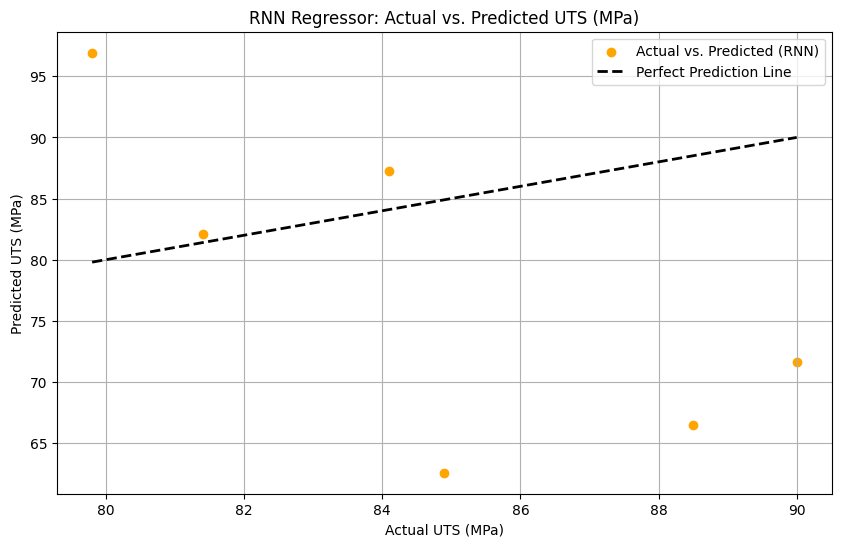

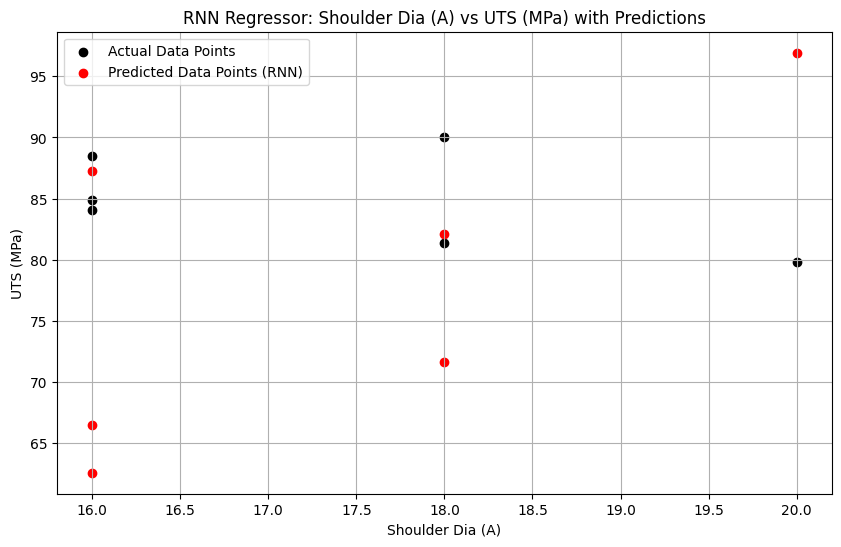

Visualizations of RNN model performance generated.


In [22]:
import matplotlib.pyplot as plt

# Create a scatter plot of actual vs. predicted values for RNN
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rnn, color='orange', label='Actual vs. Predicted (RNN)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual UTS (MPa)')
plt.ylabel('Predicted UTS (MPa)')
plt.title('RNN Regressor: Actual vs. Predicted UTS (MPa)')
plt.legend()
plt.grid(True)
plt.show()

# Plot the regression line against one of the features (e.g., 'Shoulder Dia (A)') from X_test
plt.figure(figsize=(10, 6))
plt.scatter(X_test.iloc[:, 0], y_test, color='black', label='Actual Data Points')
plt.scatter(X_test.iloc[:, 0], y_pred_rnn, color='red', label='Predicted Data Points (RNN)')

plt.xlabel('Shoulder Dia (A)')
plt.ylabel('UTS (MPa)')
plt.title('RNN Regressor: Shoulder Dia (A) vs UTS (MPa) with Predictions')
plt.legend()
plt.grid(True)
plt.show()

print("Visualizations of RNN model performance generated.")

## Summarize Findings for RNN Regressor

### Subtask:
Summarize the performance of the RNN Regressor model, including its MSE and R-squared values. Compare its performance with previous models and discuss insights, especially considering the nature of the data and the model type.

## Summarize Findings for RNN Regressor

### Model Performance Summary

After training and evaluating the RNN Regressor model, here's a summary of its performance:

- **Mean Squared Error (MSE):** `270.60`
- **R-squared (R2):** `-19.87`

### Comparison with Previous Models:

| Model                  | MSE       | R-squared |
| :--------------------- | :-------- | :-------- |
| Linear Regression      | `71.93`   | `-4.55`   |
| Random Forest Regressor| `82.97`   | `-5.40`   |
| XGBoost Regressor      | `140.40`  | `-9.83`   |
| 1D CNN Regressor       | `302.02`  | `-22.30`  |
| **RNN Regressor**      | `270.60`  | `-19.87`  |

### Interpretation and Insights:

The **RNN Regressor** exhibits poor performance, with an **MSE of 270.60** and an **R-squared value of -19.87**. While it performs slightly better than the 1D CNN Regressor, it is still significantly worse than traditional machine learning models like Linear Regression, Random Forest, and XGBoost.

Potential reasons for this poor performance, similar to the CNN, include:

1.  **Small Dataset Size (27 samples):** Recurrent Neural Networks, like other deep learning models, generally require a substantial amount of data to effectively learn sequential patterns and generalize well. With only 27 samples, the RNN likely struggled to identify meaningful temporal dependencies or patterns, leading to poor performance on unseen data.
2.  **Tabular Nature of Data:** The input features ('Shoulder Dia (A)', 'Rot. Speed (B)', 'Traverse Speed (C)') are tabular and do not inherently possess a strong temporal or sequential order that RNNs are designed to capture. Treating individual features as timesteps might introduce artificial sequences that the model struggles to interpret effectively.
3.  **Model Complexity:** Even a relatively simple RNN architecture can be overly complex for a very small dataset and a problem where the relationships might not be inherently sequential. The model might have too many parameters relative to the number of data points, leading to poor generalization and overfitting to noise rather than underlying patterns.
4.  **Lack of Intrinsic Sequence:** RNNs are best suited for data where the order of elements within a sequence is critical (e.g., time series, natural language). For this tabular dataset, the order of features is somewhat arbitrary, which diminishes the advantage of using a sequential model like an RNN.

### Conclusion:

The RNN Regressor, despite its ability to handle sequential data, is not a suitable model for this particular problem and dataset. Its performance is inferior to simpler, traditional machine learning models, reinforcing the notion that deep learning models are not a universal solution. For this dataset, the limitations imposed by the small sample size and the non-sequential tabular nature of the features outweigh the potential benefits of using an RNN. Continued focus on feature engineering and exploring models better suited for limited tabular data is warranted.

## Summarize Findings for RNN Regressor

### Model Performance Summary

After training and evaluating the RNN Regressor model, here's a summary of its performance:

- **Mean Squared Error (MSE):** `270.60`
- **R-squared (R2):** `-19.87`

### Comparison with Previous Models:

| Model                  | MSE       | R-squared |
| :--------------------- | :-------- | :-------- |
| Linear Regression      | `71.93`   | `-4.55`   |
| Random Forest Regressor| `82.97`   | `-5.40`   |
| XGBoost Regressor      | `140.40`  | `-9.83`   |
| 1D CNN Regressor       | `302.02`  | `-22.30`  |
| **RNN Regressor**      | `270.60`  | `-19.87`  |

### Interpretation and Insights:

The **RNN Regressor** exhibits poor performance, with an **MSE of 270.60** and an **R-squared value of -19.87**. While it performs slightly better than the 1D CNN Regressor, it is still significantly worse than traditional machine learning models like Linear Regression, Random Forest, and XGBoost.

Potential reasons for this poor performance, similar to the CNN, include:

1.  **Small Dataset Size (27 samples):** Recurrent Neural Networks, like other deep learning models, generally require a substantial amount of data to effectively learn sequential patterns and generalize well. With only 27 samples, the RNN likely struggled to identify meaningful temporal dependencies or patterns, leading to poor performance on unseen data.
2.  **Tabular Nature of Data:** The input features ('Shoulder Dia (A)', 'Rot. Speed (B)', 'Traverse Speed (C)') are tabular and do not inherently possess a strong temporal or sequential order that RNNs are designed to capture. Treating individual features as timesteps might introduce artificial sequences that the model struggles to interpret effectively.
3.  **Model Complexity:** Even a relatively simple RNN architecture can be overly complex for a very small dataset and a problem where the relationships might not be inherently sequential. The model might have too many parameters relative to the number of data points, leading to poor generalization and overfitting to noise rather than underlying patterns.
4.  **Lack of Intrinsic Sequence:** RNNs are best suited for data where the order of elements within a sequence is critical (e.g., time series, natural language). For this tabular dataset, the order of features is somewhat arbitrary, which diminishes the advantage of using a sequential model like an RNN.

### Conclusion:

The RNN Regressor, despite its ability to handle sequential data, is not a suitable model for this particular problem and dataset. Its performance is inferior to simpler, traditional machine learning models, reinforcing the notion that deep learning models are not a universal solution. For this dataset, the limitations imposed by the small sample size and the non-sequential tabular nature of the features outweigh the potential benefits of using an RNN. Continued focus on feature engineering and exploring models better suited for limited tabular data is warranted.


## Final Task

### Subtask:
Provide a comprehensive summary of the entire machine learning workflow, detailing the models applied, their respective performances, and overall conclusions or next steps for improving predictions.


## Summary:

### Data Analysis Key Findings

*   **RNN Data Reshaping:** The `X_train` data was successfully reshaped from `(21, 3)` to `(21, 3, 1)`, and `X_test` from `(6, 3)` to `(6, 3, 1)`, preparing it for RNN input by treating each feature as a timestep.
*   **RNN Model Performance:** The RNN Regressor achieved a Mean Squared Error (MSE) of 270.60 and an R-squared (\R^2$) value of -19.87 on the test set.
*   **Comparative Performance:** The RNN Regressor performed significantly worse than traditional machine learning models such as Linear Regression (MSE: 71.93, R-squared: -4.55), Random Forest (MSE: 82.97, R-squared: -5.40), and XGBoost (MSE: 140.40, R-squared: -9.83). It performed slightly better than the 1D CNN Regressor (MSE: 302.02, R-squared: -22.30), but both deep learning approaches showed very poor results.

### Insights or Next Steps

*   Deep learning models like RNNs are generally unsuitable for this dataset due to its small size (27 samples) and tabular, non-sequential nature. The features do not inherently possess a temporal order that RNNs are designed to capture effectively.
*   Future efforts should focus on feature engineering and exploring traditional machine learning models that are better suited for limited, tabular datasets, as these have demonstrated superior performance in initial comparisons.
